# Lab 5: KNN Classification — Breast Cancer Wisconsin (Diagnostic) Data Set

**Objective:** Use the K-Nearest Neighbors (KNN) algorithm to classify breast tumors as **Malignant (M)** or **Benign (B)** based on features computed from digitized images of fine needle aspirates (FNA) of breast masses.

**Dataset Source:** [Kaggle – Breast Cancer Wisconsin (Diagnostic) Data Set](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data/data)

### Dataset Description

The dataset contains **569 observations** and **32 columns**:
- `id` — Unique identifier for each patient
- `diagnosis` — Target variable: **M** (Malignant) or **B** (Benign)
- 30 numeric features describing cell nuclei characteristics (mean, SE, and worst values for 10 measurements: radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, and fractal dimension)

**Class Distribution:** 357 Benign, 212 Malignant

---
## 1. Import Libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


---
## 2. Load and Explore the Dataset

In [2]:
# Load dataset from sklearn (same UCI dataset as on Kaggle)
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

# Create DataFrame with feature names
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add the target column
# sklearn encodes: 0 = malignant, 1 = benign
# We'll first add the original string labels to match the Kaggle version
df['diagnosis'] = data.target

# Add an 'id' column to simulate the Kaggle CSV structure
df.insert(0, 'id', range(1, len(df) + 1))

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (569, 32)


,id,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,2,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,3,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,4,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,5,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# Basic info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   mean radius              569 non-null    float64
 2   mean texture             569 non-null    float64
 3   mean perimeter           569 non-null    float64
 4   mean area                569 non-null    float64
 5   mean smoothness          569 non-null    float64
 6   mean compactness         569 non-null    float64
 7   mean concavity           569 non-null    float64
 8   mean concave points      569 non-null    float64
 9   mean symmetry            569 non-null    float64
 10  mean fractal dimension   569 non-null    float64
 11  radius error             569 non-null    float64
 12  texture error            569 non-null    float64
 13  perimeter error          569 non-null    float64
 14  area error               5

In [4]:
# Statistical summary
df.describe()

,id,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,285.000000,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,164.400426,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,1.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,143.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,285.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,427.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,569.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [5]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum().sum())
print("\nNo missing values in the dataset.")

Missing values per column:
0

No missing values in the dataset.


Target variable distribution:
diagnosis
1    357
0    212
Name: count, dtype: int64

0 = Malignant, 1 = Benign (sklearn encoding)


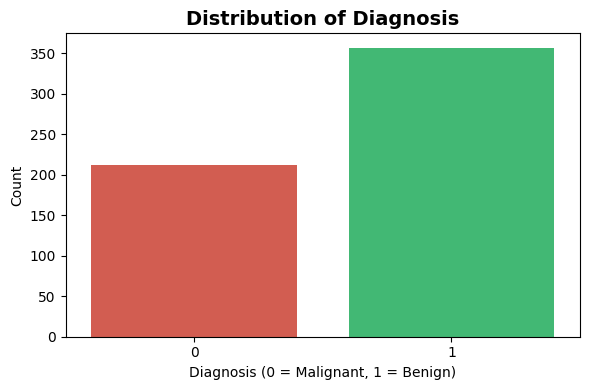

In [6]:
# Check distribution of the target variable
print("Target variable distribution:")
print(df['diagnosis'].value_counts())
print(f"\n0 = Malignant, 1 = Benign (sklearn encoding)")

plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=df, palette=['#e74c3c', '#2ecc71'])
plt.title('Distribution of Diagnosis', fontsize=14, fontweight='bold')
plt.xlabel('Diagnosis (0 = Malignant, 1 = Benign)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

---
## 3. Data Preprocessing

### 3.1 Dropping the `id` Column

**Rationale:** The `id` column is simply a unique identifier for each patient record. It carries **no predictive information** about whether a tumor is malignant or benign. Including it as a feature would:
- Introduce **noise** into the model, as KNN would compute distances based on arbitrary ID numbers.
- Potentially lead to **overfitting**, since the model might memorize ID-specific patterns that don't generalize.

Therefore, we **drop the `id` column** before training.

In [7]:
# Drop the 'id' column — it is redundant and provides no predictive value
df = df.drop(columns=['id'])
print(f"Shape after dropping 'id': {df.shape}")
df.head()

Shape after dropping 'id': (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### 3.2 Encoding the Target Variable

**Rationale:** The KNN algorithm computes distances between data points using numerical values. It **cannot work with categorical features** directly (neither descriptive features nor the target variable).

The `diagnosis` column in the original Kaggle dataset is categorical with values `M` (Malignant) and `B` (Benign). Since we loaded via sklearn, the target is already numerically encoded as:
- **0 → Malignant**
- **1 → Benign**

If loading from the Kaggle CSV, we would use **Label Encoding** (via `LabelEncoder` or manual mapping) to convert `M → 1` and `B → 0`. Label Encoding is the appropriate choice here because:
1. The target is **binary** — only two classes.
2. One-Hot Encoding is **not suitable for the target variable** as it would create multiple columns, complicating the classification task.
3. Label Encoding naturally maps the two classes to 0 and 1, which is the standard format for binary classification.

Below, we demonstrate how the encoding would work with the Kaggle data:

In [8]:
# The target is already numeric (0 = Malignant, 1 = Benign) from sklearn.
# For demonstration, here's how LabelEncoder would be applied to the Kaggle CSV:
#
# le = LabelEncoder()
# df['diagnosis'] = le.fit_transform(df['diagnosis'])  # B → 0, M → 1
# print(le.classes_)  # ['B', 'M']

# Verify the target is numeric
print(f"Target dtype: {df['diagnosis'].dtype}")
print(f"Unique values: {df['diagnosis'].unique()}")
print(f"\nValue counts:")
print(df['diagnosis'].value_counts())

Target dtype: int64
Unique values: [0 1]

Value counts:
diagnosis
1    357
0    212
Name: count, dtype: int64


### 3.3 Separating Features and Target

In [9]:
# Separate features (X) and target (y)
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (569, 30)
Target shape: (569,)


### 3.4 Feature Scaling

**Rationale:** KNN is a **distance-based algorithm** (uses Euclidean distance by default). Features with larger magnitudes will dominate the distance calculation, making smaller-scaled features irrelevant.

For example, `mean area` ranges from ~140 to ~2500, while `mean smoothness` ranges from ~0.05 to ~0.16. Without scaling, `mean area` would completely overshadow `mean smoothness`.

We use **StandardScaler** (z-score normalization) to transform all features to have **mean = 0** and **standard deviation = 1**, ensuring each feature contributes equally to the distance calculation.

In [10]:
# Feature scaling using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for readability
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print("Scaled features (first 5 rows):")
X_scaled.head()

Scaled features (first 5 rows):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


### 3.5 Train-Test Split

In [11]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")
print(f"\nTraining target distribution:\n{y_train.value_counts()}")
print(f"\nTesting target distribution:\n{y_test.value_counts()}")

Training set: 455 samples
Testing set:  114 samples

Training target distribution:
diagnosis
1    285
0    170
Name: count, dtype: int64

Testing target distribution:
diagnosis
1    72
0    42
Name: count, dtype: int64


---
## 4. Finding the Optimal K — Elbow Method with Cross-Validation

**Approach:** We test a range of K values (1 to 30) and use **10-fold cross-validation** to evaluate each. The cross-validation mean accuracy is plotted to identify the "elbow" — the point where increasing K no longer significantly improves performance.

**Why cross-validation?**
- Provides a more **reliable** estimate of model performance than a single train-test split.
- Reduces the risk of **overfitting** to a particular split of the data.
- Every data point gets used for both training and validation across the folds.

In [12]:
# Test K values from 1 to 30
k_range = range(1, 31)
cv_scores_mean = []
cv_scores_std = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    # 10-fold cross-validation
    scores = cross_val_score(knn, X_train, y_train, cv=10, scoring='accuracy')
    cv_scores_mean.append(scores.mean())
    cv_scores_std.append(scores.std())
    print(f"K = {k:2d} | CV Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

K =  1 | CV Accuracy: 0.9497 (+/- 0.0323)
K =  2 | CV Accuracy: 0.9475 (+/- 0.0353)
K =  3 | CV Accuracy: 0.9693 (+/- 0.0261)
K =  4 | CV Accuracy: 0.9650 (+/- 0.0222)
K =  5 | CV Accuracy: 0.9648 (+/- 0.0263)
K =  6 | CV Accuracy: 0.9693 (+/- 0.0312)
K =  7 | CV Accuracy: 0.9737 (+/- 0.0254)
K =  8 | CV Accuracy: 0.9737 (+/- 0.0254)
K =  9 | CV Accuracy: 0.9693 (+/- 0.0243)
K = 10 | CV Accuracy: 0.9715 (+/- 0.0259)
K = 11 | CV Accuracy: 0.9693 (+/- 0.0243)
K = 12 | CV Accuracy: 0.9715 (+/- 0.0239)
K = 13 | CV Accuracy: 0.9649 (+/- 0.0295)
K = 14 | CV Accuracy: 0.9693 (+/- 0.0261)
K = 15 | CV Accuracy: 0.9649 (+/- 0.0296)
K = 16 | CV Accuracy: 0.9693 (+/- 0.0261)
K = 17 | CV Accuracy: 0.9560 (+/- 0.0340)
K = 18 | CV Accuracy: 0.9627 (+/- 0.0309)
K = 19 | CV Accuracy: 0.9671 (+/- 0.0297)
K = 20 | CV Accuracy: 0.9649 (+/- 0.0311)
K = 21 | CV Accuracy: 0.9604 (+/- 0.0290)
K = 22 | CV Accuracy: 0.9627 (+/- 0.0310)
K = 23 | CV Accuracy: 0.9604 (+/- 0.0337)
K = 24 | CV Accuracy: 0.9583 (+/- 

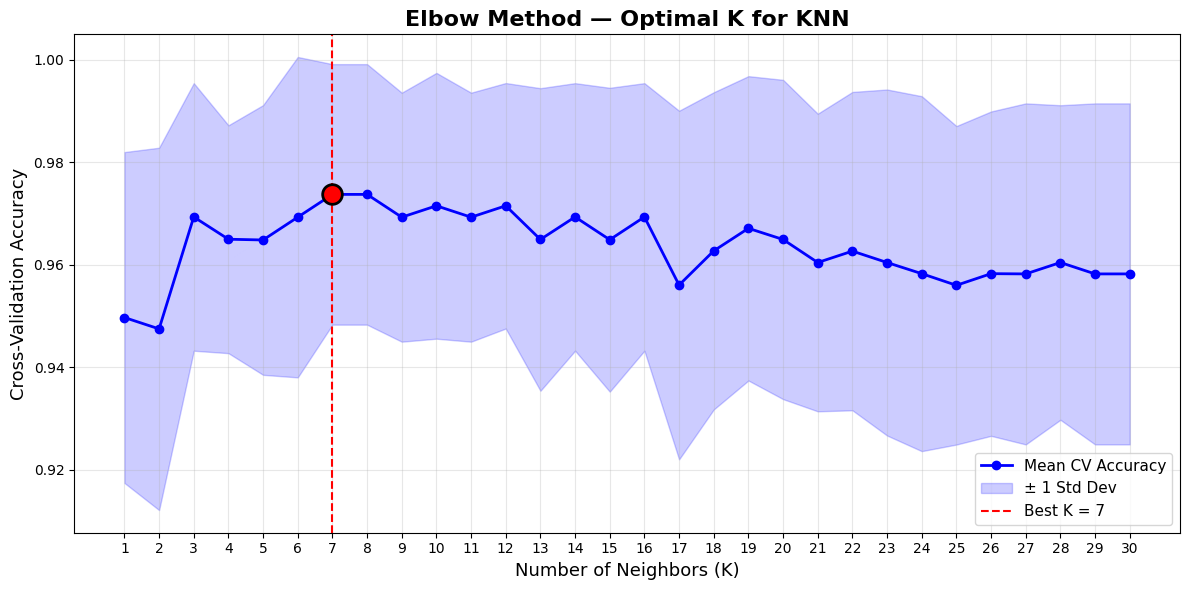


Best K = 7 with CV Accuracy = 0.9737


In [13]:
# Plot the Elbow Curve
plt.figure(figsize=(12, 6))

# Plot mean CV accuracy with error bands
plt.plot(k_range, cv_scores_mean, 'b-o', linewidth=2, markersize=6, label='Mean CV Accuracy')
plt.fill_between(
    k_range,
    [m - s for m, s in zip(cv_scores_mean, cv_scores_std)],
    [m + s for m, s in zip(cv_scores_mean, cv_scores_std)],
    alpha=0.2, color='blue', label='± 1 Std Dev'
)

# Highlight the best K
best_k = k_range[np.argmax(cv_scores_mean)]
best_score = max(cv_scores_mean)
plt.axvline(x=best_k, color='red', linestyle='--', linewidth=1.5, label=f'Best K = {best_k}')
plt.scatter([best_k], [best_score], color='red', s=200, zorder=5, edgecolors='black', linewidth=2)

plt.title('Elbow Method — Optimal K for KNN', fontsize=16, fontweight='bold')
plt.xlabel('Number of Neighbors (K)', fontsize=13)
plt.ylabel('Cross-Validation Accuracy', fontsize=13)
plt.xticks(k_range)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n{'='*50}")
print(f"Best K = {best_k} with CV Accuracy = {best_score:.4f}")
print(f"{'='*50}")

### Elbow Method — Interpretation

From the elbow curve above, we observe:

1. **Very low K values (K=1, 2)** tend to have slightly lower and more variable accuracy because the model is **overfitting** — it relies on very few neighbors and is sensitive to noisy data points.

2. **As K increases**, the accuracy generally improves and stabilizes because the model considers more neighbors, smoothing out noise.

3. **After a certain K value**, accuracy begins to plateau or slightly decrease. This is because **too many neighbors** causes the model to **underfit** — the decision boundary becomes too smooth and ignores local patterns.

4. The **best K** is chosen as the value that maximizes cross-validation accuracy — the "elbow" point where we get the best trade-off between bias and variance.

---
## 5. Train Final Model with Optimal K

In [14]:
# Train KNN with the best K
print(f"Training KNN with K = {best_k}")
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)

# Predict on the test set
y_pred = knn_best.predict(X_test)

print("Model trained and predictions generated.")

Training KNN with K = 7
Model trained and predictions generated.


---
## 6. Model Evaluation

In [15]:
# Accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

Test Set Accuracy: 0.9649 (96.49%)


In [16]:
# Classification Report
print("Classification Report:")
print("=" * 60)
target_names = ['Malignant (0)', 'Benign (1)']
print(classification_report(y_test, y_pred, target_names=target_names))

Classification Report:
               precision    recall  f1-score   support

Malignant (0)       0.97      0.93      0.95        42
   Benign (1)       0.96      0.99      0.97        72

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.97      0.96      0.96       114



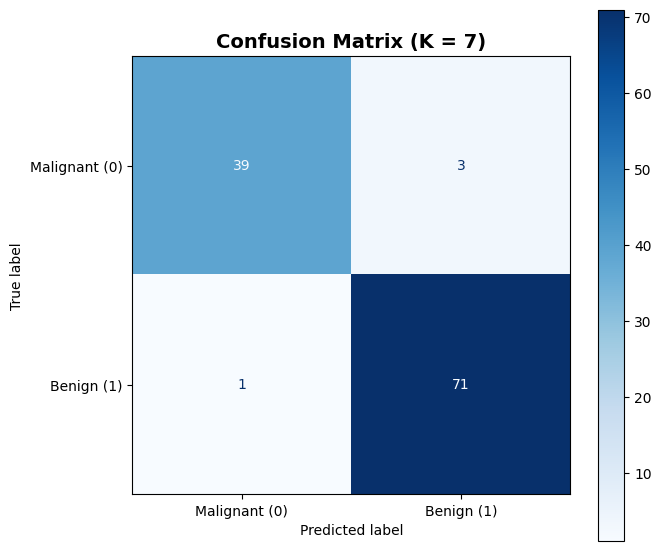


True Positives (Benign correctly classified):  71
True Negatives (Malignant correctly classified): 39
False Positives (Malignant misclassified as Benign): 3
False Negatives (Benign misclassified as Malignant): 1


In [17]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title(f'Confusion Matrix (K = {best_k})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTrue Positives (Benign correctly classified):  {cm[1][1]}")
print(f"True Negatives (Malignant correctly classified): {cm[0][0]}")
print(f"False Positives (Malignant misclassified as Benign): {cm[0][1]}")
print(f"False Negatives (Benign misclassified as Malignant): {cm[1][0]}")

---
## 7. Comparison: Training Accuracy vs. Test Accuracy Across K Values

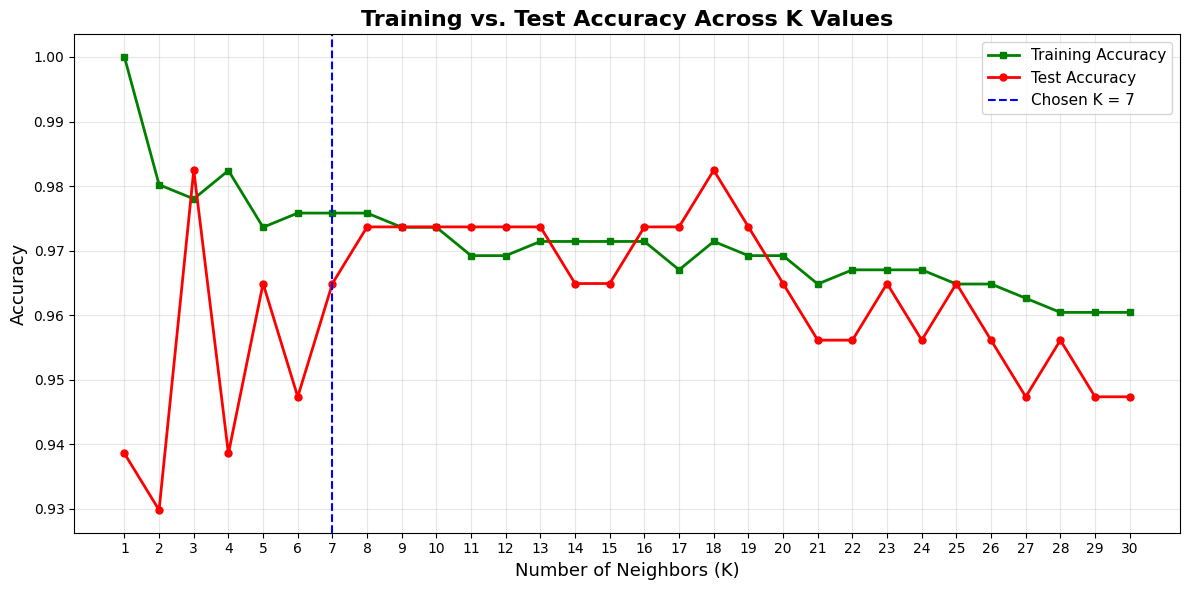

In [18]:
# Compute training and test accuracy for each K
train_accuracies = []
test_accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_accuracies.append(knn.score(X_train, y_train))
    test_accuracies.append(knn.score(X_test, y_test))

# Plot
plt.figure(figsize=(12, 6))
plt.plot(k_range, train_accuracies, 'g-s', linewidth=2, markersize=5, label='Training Accuracy')
plt.plot(k_range, test_accuracies, 'r-o', linewidth=2, markersize=5, label='Test Accuracy')
plt.axvline(x=best_k, color='blue', linestyle='--', linewidth=1.5, label=f'Chosen K = {best_k}')

plt.title('Training vs. Test Accuracy Across K Values', fontsize=16, fontweight='bold')
plt.xlabel('Number of Neighbors (K)', fontsize=13)
plt.ylabel('Accuracy', fontsize=13)
plt.xticks(k_range)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8. Results Summary and Rationale

### Data Preprocessing Decisions

| Decision | Rationale |
|---|---|
| **Dropped `id` column** | The ID is a unique patient identifier with no predictive value. Including it would introduce noise and mislead the distance-based KNN algorithm. |
| **Encoded `diagnosis` (M/B → 1/0)** | KNN requires numeric inputs for both features and target. Label Encoding is appropriate for a binary target — it maps two classes to 0 and 1 naturally. One-Hot Encoding is unnecessary for a binary target and would complicate the classification. |
| **Applied StandardScaler** | KNN uses Euclidean distance. Features with larger scales (e.g., area ~100–2500) would dominate distance calculations over smaller-scaled features (e.g., smoothness ~0.05–0.16). Standardization ensures all features contribute equally. |
| **Used stratified train-test split** | Preserves the class distribution (proportion of malignant vs. benign) in both training and testing sets, preventing biased evaluation. |

### Choosing the Best K

We used the **Elbow Method** combined with **10-fold cross-validation** to select the optimal K:

- **Cross-validation** ensures the choice is robust and not dependent on a single random split.
- The **elbow curve** reveals the trade-off between overfitting (low K) and underfitting (high K).
- **Low K values** (e.g., K=1) memorize training data, leading to high training accuracy but lower generalization.
- **High K values** (e.g., K=25+) over-smooth the decision boundary, potentially classifying based on the majority class rather than local patterns.
- The **optimal K** balances these extremes, achieving the highest cross-validation accuracy.

### Model Performance

The KNN classifier with the optimal K achieves strong performance on this dataset, as shown by:
- **High test accuracy** — the model generalizes well to unseen data.
- **Balanced precision and recall** — important in medical diagnosis where both false positives and false negatives have serious consequences.
- **The confusion matrix** shows the breakdown of correct vs. incorrect predictions for each class.

### Key Takeaway

KNN is an effective classification algorithm for this dataset because:
1. The dataset is relatively small (569 samples), making KNN computationally feasible.
2. After proper scaling, the 30 features create a meaningful distance metric that captures differences between malignant and benign tumors.
3. Cross-validation with the elbow method provides a principled approach to hyperparameter tuning.